# Árboles de Decisión en la detección de SPAM

## Preparación del entorno
Importación de las librerías necesarias para la ejecución del cuaderno.

**OBSERVACIÓN**: Incluye la librería de lematización de spacy. Esta librería requiere tener descargado el modelo de lematización previo a ser usado. Si no lo tienes descargado en tu entorno fallará.
Recuerda que para descargarlo deberás utilizar alguna de las instrucciones siguientes desde tu entorno Python dependiendo del modelo de lematización que quieras utilizar:
- `python -m spacy download es_core_news_sm`
- `python -m spacy download es_core_news_md`

In [4]:
!pip install scikit-learn
!pip install matplotlib
!pip install dtreeviz
!pip install nltk
!pip install seaborn
!pip install spacy
!pip install joblib
!pip install plotly
!python -m spacy download es_core_news_sm


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached typer-0.27.3-py3-none-any.whl.metadata (16 kB)
  Using cached pydantic-2.14.0-py3-none-any.whl.metadata (131 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached typing_inspection-0.4.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.5-py3-none-any.whl.metadata (6.5 kB)
  Using cached cloudpathlib-0.26.0-py3-none-any.


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ------------------------------- ------- 10.5/12.9 MB 65.1 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 44.8 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from collections import Counter
import string
import re
import random

import pandas as pd
import numpy as np

# Descargamos los recursos necesarios de NLTK si es que no existen previamente en el entorno.
import nltk
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

# Módulos necesarios de NLTK que utilizaremos para el preprocesamiento de la información.
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Lematización
# Para que funcione la carga del modelo de lematización este tiene que estar descargado en el entorno primeramente.
# Para ello se puede utilizar alguna de las instrucciones siguientes desde tu entorno Python dependiendo del modelo de lematización que quieras utilizar:
# python -m spacy download es_core_news_sm (modelo pequeño)
# python -m spacy download es_core_news_md (modelo mediano)
import spacy
nlp = spacy.load("es_core_news_sm")
# nlp = spacy.load("es_core_news_md")

# Stemming
from nltk.stem import SnowballStemmer

# Módulos necesarios de la librería Scikit-Learn que vamos a utilizar para a construcción del modelo TF-IDF.
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Para este ejemplo de Regresión Logística en el que utilizamos un Pipeline
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, export_graphviz
from sklearn.ensemble import RandomForestClassifier

# Representaciones gráficas varias ...
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Importar la herramienta 3D
import plotly.express as px
import seaborn as sns
from dtreeviz import model

# Persistencia de modelos
import joblib

## Configuración del experimento

In [7]:
SPAM_DATASET= "spam_dataset.csv"
RANDOM_SEED = 202510  # Semilla para la reproducibilidad de los resultados (No tocar para poder comparar resultados)

## Función de preprocesamiento del texto

In [8]:
def preprocesar_documento(documento):
    """
    Función para preprocesar un documento individual
    
    Args:
        documento (str): Texto del documento a preprocesar
    
    Returns:
        list: Lista de tokens normalizados para el texto a preprocesar.
    """
    # Convertir a minúsculas
    documento = documento.lower()
    
    # Eliminar signos de puntuación usando expresiones regulares
    # documento = re.sub(r'[^\w\s]', '', documento)
    
    # Tokenizar usando NLTK
    tokens = word_tokenize(documento, language='spanish')

    # Eliminación de puntuación y stopwords
    stop_words = set(stopwords.words("spanish"))
    tokens_limpios = [t for t in tokens if t not in string.punctuation and t not in stop_words]
    
    # Filtrar tokens que no sean alfabéticos (eliminar números)
    tokens_filtrados = [token for token in tokens_limpios if token.isalpha()]

    # Lamtización usando spaCy
    doc_spacy = nlp(" ".join(tokens_filtrados))
    tokens_lemmatizados = [token.lemma_ for token in doc_spacy] 
    
    return tokens_lemmatizados

## Lectura del dataset

In [9]:
spam_df = pd.read_csv(SPAM_DATASET)

# Muestra total de registros
print("Número total de registros en el dataset:", spam_df.shape[0])

# Muestra las columnas del dataset
print("Columnas del dataset:", spam_df.columns.tolist())

# Muestra las primeras filas del dataset y la distribución de categorías
display(spam_df)
print("Distribución por categorías:")
print(spam_df['tipo'].value_counts())

# Calculamos el porcentaje de cada categoría
total_registros = spam_df.shape[0]
distribucion_porcentaje = (spam_df['tipo'].value_counts() / total_registros) * 100
print("Distribución porcentual por categorías:")
print(distribucion_porcentaje)

Número total de registros en el dataset: 1207
Columnas del dataset: ['mensaje', 'tipo']


,mensaje,tipo
0,Compra ahora y recibe un descuento especial,legítimo
1,Haz clic aqui para ganar un premio,spam
2,Tu ordenador tiene un virus,spam
3,Descubre como perder peso rapidamente,spam
4,Necesitas ayuda con tu tarea,legítimo
...,...,...
1202,Tu nomina esta disponible para descargar,legítimo
1203,Baja 2 kilos por semana con nuestra dieta,spam
1204,Elige entre debito o credito,legítimo
1205,Salva una vida donando sangre hoy,legítimo


Distribución por categorías:
tipo
spam        621
legítimo    586
Name: count, dtype: int64
Distribución porcentual por categorías:
tipo
spam        51.449876
legítimo    48.550124
Name: count, dtype: float64


## Definición de los conjuntos de entrenamiento y pruebas

In [10]:
def split_dataset(dataset= None, stratify_column= None, test_size=0.1, random_state=RANDOM_SEED):
    """ 
    Divide el dataset en conjuntos de entrenamiento y test.
    Mantiene la proporción de registros (test_size) dependiendo del valor del valor del parámetro stratify_column.

    Parámetros:
        dataset (DataFrame): El DataFrame completo a dividir.
        stratify_column (str): El nombre de la columna para estratificar.
        test_size (float): La proporción del dataset que se destina a test.
        random_state (int): Semilla para la reproducibilidad.
    """
    train_df, test_df = train_test_split(
        dataset, 
        test_size=test_size, 
        stratify= dataset[stratify_column], 
        random_state=RANDOM_SEED
    )
    return train_df, test_df


stratify_column= "tipo"

# Genera los conjuntos de entrenamiento y test
train_df, test_df = split_dataset(
    dataset= spam_df,
    test_size= 0.2, # Especificamos un 20% del total del dataset original para el conjunto de pruebas.
    stratify_column= stratify_column
)
# Muestra los datasets generados para entrenamiento y test.
print("\nConjunto de Entrenamiento:")
print(train_df[stratify_column].value_counts())
display(train_df)
print("\nConjunto de Test:")
print(test_df[stratify_column].value_counts())
display(test_df)


Conjunto de Entrenamiento:
tipo
spam        496
legítimo    469
Name: count, dtype: int64


,mensaje,tipo
506,Agradecemos tus ideas nos ayudan a mejorar,legítimo
171,Unete a nuestro club de lectores y recibe libr...,spam
766,Adjunta una copia de tu cédula,spam
426,Necesitamos verificar tu licencia de conducir ...,spam
462,Protege tu hogar con nuestro seguro contra des...,spam
...,...,...
52,Tu cuenta ha sido bloqueada temporalmente,spam
321,Gana una consola de videojuegos en nuestro con...,spam
815,Gracias por confiar en nuestra asesoría,legítimo
1018,Usa nuestra app y acumula puntos canjeables,spam



Conjunto de Test:
tipo
spam        125
legítimo    117
Name: count, dtype: int64


,mensaje,tipo
605,Reconfirma tu correo para evitar suspensiones,spam
247,Has ganado una gift card para tu tienda favorita,spam
287,Lamentamos informarte que tu postulación no ha...,legítimo
40,Haz esta prueba de coeficiente intelectual y s...,spam
15,Gracias por tu compra,legítimo
...,...,...
667,Actualiza tu método de pago,legítimo
595,Bienvenido a nuestro selecto club,legítimo
213,Aprovecha nuestro financiamiento sin intereses,spam
420,Hola ¿te gustaría colaborar en nuestro proyecto?,legítimo


## Pre-Procesado de los documentos de entrenamiento
Necesitamos procesar los documentos que vamos a utilizar en el entrenamiento antes de vectorizarlos.

In [11]:
train_documentos_procesados = []
for i, doc in enumerate(train_df['mensaje']):
    tokens = preprocesar_documento(doc)
    train_documentos_procesados.append(" ".join(tokens))

# Número de documentos de entrenamiento procesados
print(f"Número de documentos de entrenamiento procesados: {len(train_documentos_procesados)}")
print(f"Documentos de entrenamiento procesados: {train_documentos_procesados[:3]}...")  # Muestra los primeros 3 documentos procesados

Número de documentos de entrenamiento procesados: 965
Documentos de entrenamiento procesados: ['agradecer idea ayudar mejorar', 'unete club lector recibir libro gratis', 'adjunto copia cédula']...


## Implementación de un Árbol de Decisión

Para esta implementación utilizaremos el componente `DecisionTreeClassifier` de la librería SciKit-Learn.

### Entrenamiento del Árbol de Decisión
Sus hiper-parámetros más interesantes son los siguientes:

- `criterion` (String. Defecto=gini): Función utilizada para la medición de la _pureza_ de las diferentes divisionies. Controla la calidad de las divisiones. Sus posibles valores son los siguientes:
    - **gini**: Índice de Gini $G = 1 - \sum_{i=1}^{K} (p_i)^2$
    - **entropy**: Medida de la Entropía (Shannon) $E = -\sum_{i=1}^{K} p_i \log_2(p_i)$
    - **log_loss**: Medida de la Entropía Cruzada $\text{LogLoss} = -\sum_{i} \sum_{c \in C} y_{ic} \log(p_{ic})$. 

- `splitter` (String. Defecto= best): Estrategia utilizada para elegir la característica y el punto de corte para cada uno de los nodos durante el entrenamiento.
    - **best**: Elige la mejor división posible entre todas las características y todos los puntos de corte según el `criterion` seleccionado. 
    - **random**: Selecciona una característica aleatoria y luego busca el mejor punto de corte sólo para esa característica.

- `max_depth` (Integer. Defecto= None): Máxima profundidad que podrá tener el árbol. Si se deja el valor por defecto `None` el átbol expandirá sus nodos hasta que todas las hojas sean puras o contengan menos elementos que los especificados en el parámetro `min_samples_split`.

- `min_samples_split`(Integer. Defecto= 2): Indica el número mínimo de elementos que debe tener un nodo para que pueda ser dividido. Es decir, si un nodo tiene menos de este valor entonces el nodo no se puede dividir más y se convierte en una hoja del árbol.

- `min_samples_leaf` (Integer: Defecto= 1): Indica el mínimo número de elementos que debe tener un nodo para ser considerado como una hoja del árbol. Cuando se hace una división en el árbol esta se podrá realizar si deja al meno este número de elementos tanto en su nodo derecho como izquierdo.

- `max_leaf_nodes` (Integer. Defecto= None): Establece el número máximo de hojas que puede tener el árbol. Es importante recordar en este punto que un nodo hoja es aquel que ya no se va a dividir más pero más importante de todo **son aquellos que emiten la predicción**. Se trata de un método de poda controlada (pre-prunning) del árbol.

- `min_impurity_decrease` (Float. Defecto= 0): Establece cuánta mejora mínima en la pureza debe lograrse para que se realice una divisón dependiendo del `criterion` elegido. Un nodo no se dividirá si no consigue mejorar la pureza al menos en ese valor. También se considera como un argumento para la poda temprana (pre-prunning) del árbol.

- `max_features`: Controla cuántas características (variables) se consideran al buscar la mejor división en cada nodo de un árbol de decisión. Se trata, esencialmente, de una forma de introducir aleatoriedad y reducir el sobreajuste (_overfitting_) del árbol. Puede tomar los siguientes valores:
    - Si especificamos un **número entero**: Utilizará exactamente ese número de características.
    - Si especificamos un **Float** ( 0 <= float <= 1): Utilizará una proporción del número de careterísticas.
    - **Otros** valores:
        - **sqrt**: Raiz cuadrada del número de características.
        - **log2**: Log2 del número de características.
        - **all**: Utilizará todas las características disponibles.

- `ccp_alpha` (Float no negativo. Defecto= 0): Parámetro que controla la _Poda por Complejidad de Coste (CCP)_. El objetivo de la poda es evitar que el árbol crezca demasiado, lo cual puede llevar a un sobreajuste (overfitting). En lugar de limitar el tamaño del árbol con parámetros tradicionales (max_depth, min_samples_split, etc.), ccp_alpha **penaliza explícitamente la complejidad del modelo**.

**CRITERIOS DE SELECCIÓN DEL PARÁMETRO `criterion`**
- Ambas medidas tienen el mismo comportamiento externo. Esto es: 0 cuando un nodo es puro yMáximo cuando las clases se encuentran perfectamente balanceadas.
- La Entropía penaliza más fuerte las distribuciones mixtas, esto es, cuando hay igual número de elementos por cada clase (máxima entropía)
- Gini es computacionalmente más ligero al no tener que calcular logaritmos.
- Cualquiera de los índices es bueno y proporciona resultados similares.
- La Medida de la Entropía Cruzada no la hemos visto en clase dentro de los modelos de Árboles de Decisión pero sí en el caso de la Regresión Logística. También se puede aplicar en árboles y lo que hace, intuitivamente, es **penalizar más aquellas prediccciones que se han realizado de manera incorrecta pero con mucha confianza**.

**CRITERIOS DE AJUSTE PARA EL PARÁMETRO `splitter`**
- **best**: Es mucho más preciso pero mucho más lento ya que explora todas las características en busca de la mejor combinación.
- **random**: Mucho más rápido pero también mucho más impreciso. Introduce aleatoriedad y esto puede resultar conveniente en casos en los que haya que reducir el _overfitting_ del modelo.

**CRITERIOS DE AJUSTE PARA EL PARÁMETRO `max_leaf_nodes`**
- Un árbol con muchas hojas puede padecer de _overfitting_.
- Un árbol con pocas hojas es mucho más simple y generaliza mejor pero puede sufrir de _underfitting_.
- Si dejamos que el árbol crezca hasta sin límite (valor `None`) tendremos un modelo muy complejo.

**CRITERIOS DE AJUSTE PARA EL PARÁMETRO `min_impurity_decrease`**
Algunos valores típicos son los siguientes:

| Valor típico        | Efecto                            | Resultado                                              |
| ------------------- | --------------------------------- | ------------------------------------------------------ |
| `0.0` (por defecto) | Cualquier mejora permite dividir  | Árbol puede crecer muy grande. Riesgo de _overfitting_ |
| `0.01`              | Solo divisiones con mejora ≥ 0.01 | Menos divisiones, árbol más general                    |
| `0.1`               | Muy exigente                      | Árbol pequeño. Riesgo de _underfitting_                |

**CRITERIOS PARA LA ELECCIÓN DEL PARÁMETRO ` max_features`**
- Un punto de partida inicial bueno suele ser utilizar `sqrt`.

**RECORDATORIO SOBRE LA PODA**
Para cada nodo $t$ del árbol se define:
$$R(t) = \text{error}(t)$$

- **Error**: en clasificación suele ser el número de muestras mal clasificadas dentro del nodo (o la pérdida de Gini/entropía).  
- $\alpha$: es el parámetro que controla la penalización.

El criterio que se minimiza para decidir si un nodo debe mantenerse o eliminarse es:
$$R_{\alpha}(t) = R(t) + \alpha \times n_{\text{leaves}}(t)$$
Donde:
- $n_{\text{leaves}}(t)$: número de hojas (sub‑árboles) que están bajo el nodo $t$.
- El término $\alpha \times n_{\text{leaves}}$ penaliza la complejidad: cuanto mayor sea $\alpha$ , más se penalizan los sub‑árboles.

A continuación algunos consejos para la elección del parámetro de ajuste de poda $\alpha$

| Puntos a tener en cuenta | Consejos |
|---------------------------|----------|
| **α muy pequeño** | El árbol casi no se poda; puede sobreajustarse. |
| **α muy grande** | El árbol queda con pocas hojas, quizá sub‑ajustado. |


Para más información se recomienda viistar la [página de la documentación oficial de SciKit-Learn al respecto del componente DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier) y la [ecplicación detallada al respecto del funcionamiento de este tipo de modelos](https://scikit-learn.org/stable/modules/tree.html).

In [12]:
# Crea el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer (
    stop_words= None,               # Ya hemos pre-procesado los documentos y les hemos eliminado las stopwords.
    ngram_range= (1,1),             # Solo vamos a utilizar unigramas (palabras individuales).
    analyzer= 'word',               # Analizamos por palabras.
    max_df= 0.5,                    # Ignora términos que aparecen en más del 50% de los documentos.
    min_df= 1,                      # Ignora términos que aparecen en menos de 1 documento.
    max_features= None              # No limitamos el número de características del vocabulario.
)

# Crear y entrenar el modelo de árbol de decisión
decission_tree = DecisionTreeClassifier (
    criterion= 'gini',              # Criterio de división de nodos.
    splitter= 'best',               # Estrategia para dividir los nodos.
    max_depth= None,                # Profundidad máxima del árbol.
    min_samples_split =4,           # Mínimo de muestras para dividir un nodo.
    min_samples_leaf= 2,            # Mínimo de muestras en una hoja.
    min_impurity_decrease= 0.01,    # Mínima disminución de impureza para dividir un nodo.
    random_state= RANDOM_SEED       # Semilla para la reproducibilidad.
)

# Montamos el pipeline de entrenamiento
decission_tree_pipeline = Pipeline(
    steps= [
        ('vectorizer', tfidf_vectorizer),
        ('classifier', decission_tree)
    ]
)

decission_tree_pipeline.fit(
    train_documentos_procesados,
    train_df['tipo']
)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


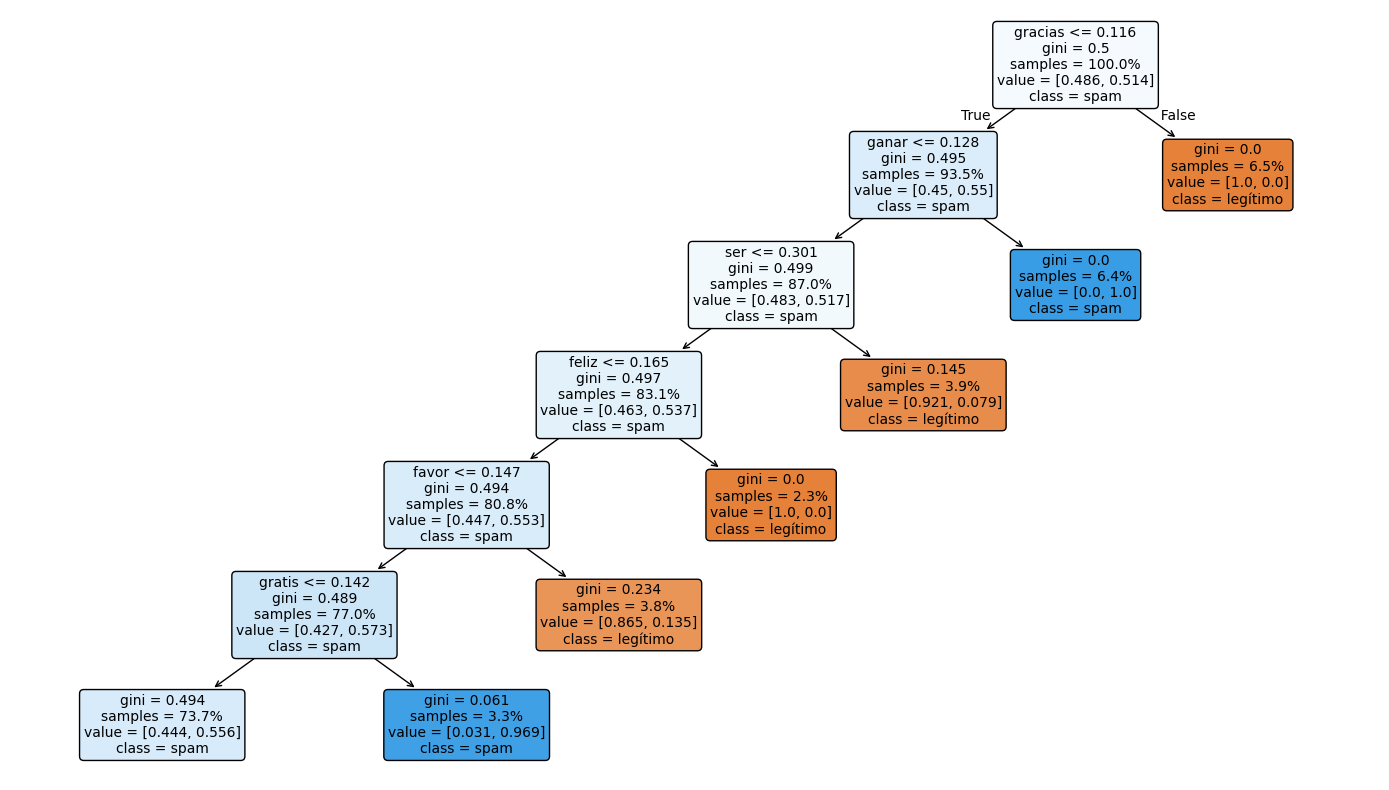

In [13]:
# Muestra el árbol de decisión entrenado de manera gráfica
plt.figure(figsize=(14,8))
plot_tree(
    decission_tree_pipeline.named_steps['classifier'],                                          # El clasificador del pipeline
    feature_names= decission_tree_pipeline.named_steps['vectorizer'].get_feature_names_out(),   # lista de nombres de features
    class_names= decission_tree_pipeline.named_steps['classifier'].classes_,                    # lista de nombres de clases
    filled=True,                   # colorea según la clase mayoritaria
    rounded=True,
    proportion=True,               # usa proporciones (en vez de conteos)
    fontsize=10
)
plt.tight_layout()
plt.show()

### Pruebas sobre el conjunto de test inicial
Vamos a realizar una prediccón inicial por medio del conjunto de test que hemos obtenido anteriormente del dataset general.
Con esto nos podemos hacer una primera idea de lo bien que se desempeña el modelo con los parámetros de entrenamiento que le hemos proporcionado inicialmente.

Número de documentos de test procesados: 242
Documentos de test procesados: ['reconfirma correo evitar suspensión', 'ganar gift card tiendo favorita', 'lamentar informarte postulación ser seleccionar']...

Evaluación del modelo de Regresión Logística en el conjunto de test:
Exactitud (Accuracy): 0.6033
Precisión (Precision): 0.5668
Exhaustividad (Recall): 0.9840
Puntuación F1 (F1 Score): 0.7193

Reporte de clasificación:
              precision    recall  f1-score   support

    legítimo       0.92      0.20      0.32       117
        spam       0.57      0.98      0.72       125

    accuracy                           0.60       242
   macro avg       0.74      0.59      0.52       242
weighted avg       0.74      0.60      0.53       242



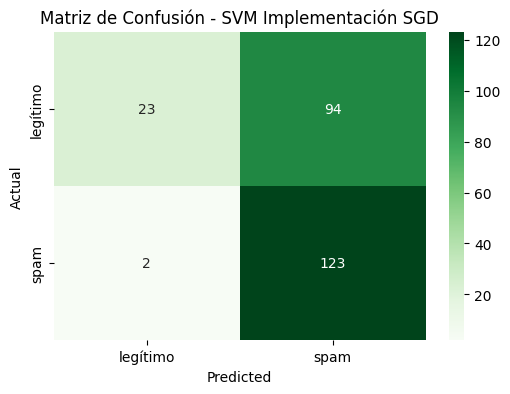

Número de fallos en las predicciones: 96


,mensaje,tipo,predicted
287,Lamentamos informarte que tu postulación no ha...,legítimo,spam
131,Este es un aviso de tu banco,legítimo,spam
539,Hemos extendido tu garantía sin costo adicional,legítimo,spam
905,Felicidades tu crédito fue pre-aprobado,legítimo,spam
1126,Construyamos juntos un mundo mejor,legítimo,spam
...,...,...,...
940,Comunicado: cambio temporal de sede,legítimo,spam
667,Actualiza tu método de pago,legítimo,spam
595,Bienvenido a nuestro selecto club,legítimo,spam
420,Hola ¿te gustaría colaborar en nuestro proyecto?,legítimo,spam


In [14]:
# Preprocesamos los documentos del conjunto de test
test_documentos_procesados = []
for i, doc in enumerate(test_df['mensaje']):
    tokens = preprocesar_documento(doc)
    test_documentos_procesados.append(" ".join(tokens)) 
# Número de documentos de test procesados
print(f"Número de documentos de test procesados: {len(test_documentos_procesados)}")
print(f"Documentos de test procesados: {test_documentos_procesados[:3]}...")  # Muestra los primeros 3 documentos procesados

# Realiza las predicciones utilizando el pipeline cargado
predicciones = decission_tree_pipeline.predict(test_documentos_procesados)

# Evalúa el rendimiento del modelo
accuracy = accuracy_score(test_df['tipo'], predicciones)
precision = precision_score(test_df['tipo'], predicciones, pos_label='spam')
recall = recall_score(test_df['tipo'], predicciones, pos_label='spam')
f1 = f1_score(test_df['tipo'], predicciones, pos_label='spam')
print("\nEvaluación del modelo de Regresión Logística en el conjunto de test:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Exhaustividad (Recall): {recall:.4f}")
print(f"Puntuación F1 (F1 Score): {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(test_df['tipo'], predicciones))

# Muestra la matriz de confusión
conf_matrix = confusion_matrix(test_df['tipo'], predicciones)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - SVM Implementación SGD')
plt.show()

# Saca los documentos que han fallado y la etiqueta real y la predicha
fallos = test_df[test_df['tipo'] != predicciones]
print(f"Número de fallos en las predicciones: {fallos.shape[0]}")
display(fallos.assign(predicted= predicciones[test_df['tipo'] != predicciones]))

### Validación Cruzada
La **validación cruzada** (cross‑validation) es una técnica de evaluación que permite estimar con mayor confianza el rendimiento de un modelo cuando se dispone de un conjunto limitado de datos.  

En lugar de dividir los datos en solo *train* y *test*, el algoritmo repite la partición varias veces, entrenando el modelo sobre distintas “folds” (subconjuntos) y evaluándolo sobre las restantes. El resultado final suele ser la media (y a veces la desviación estándar) de todas esas iteraciones.

Para realizar una validación cruzada en SciKit-Learn utilizaremos el componente `StratifiedKFold` para definir la configuración del proceso cross-validation que queremos realizar.

Los parámetros que acepta el componente `StratifiedKFold` son los siguientes:

- `n-splits` (Integer. Defecto= 5): Número de particiones que deseamos realizar sobre el conjunto de datos de entrenamiento para realizar el proceso de validación cruzada.
- `shuffle` (Boolean. Defecto= False): Si es True, se barajan los datos antes de crear las particiones. Es útil cuando la distribución de clases no está balanceada en el dataset original.
- `random_state` (Integer): Fija un valor de reproducibilidad del experimento.

Para realizar el proceso llamaremos a la función `cross_val_score` cuyos parmetros son los siguientes:

- `estimator`: El objeto que hemos utilizado para realizar el `fit` del modelo. En nuestro caso es el pipeline que hemos configurado anteriormente con el vectorizador tf-idf y el clasificador por Regresión Logística.
- `X`: datos preprocesados de entrenamientos.
- `y`: Clases utilizadas en el entrenamiento.
- `cv`: El Cross Validator que le pasamos con la configuración que tiene que utilizar para realizar la operacion de validación cruzada
- `scoring` (String accuracy | f1 | ...): Métrica a utilizar para evaluar el desempeño del modelo. Se pueden consultar las diferentes métricas que se pueden indicar en el [siguiente enlace](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names).

**Ventajas de realizar un proceso de validación cruzada**
- **Reducción del sesgo**: No dependemos de una sola partición aleatoria.
- **Uso eficiente de los datos**: Cada partición se utiliza tanto para entrenamiento como para prueba.
- **Información de variabilidad**: Permite ver cómo varía el rendimiento entre distintas particiones.

Para más información se recomienda visitar las siguientes páginas:
- [Página de la documentación oficial de SciKit-Learn correspondiente al componente StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)]
- [Documentación oficial sobre la función cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)

In [15]:
# Configuramos el cross validator estratificado
cross_validator = StratifiedKFold (
    n_splits= 10,                               # Número de folds
    shuffle= True,                              # Mezcla los datos antes de dividir
    random_state= RANDOM_SEED                   # Semilla para reproducibilidad
)

# Realiza la validación cruzada...
scores = cross_val_score(
    estimator= decission_tree_pipeline,         # Pipeline de Regresión Logística
    X= train_documentos_procesados,             # Documentos de entrenamiento preprocesados
    y= train_df['tipo'],                        # Etiquetas (clases) de entrenamiento
    cv=cross_validator,                         # Validador cruzado estratificado 
    scoring='accuracy'                          # Métrica de evaluación
)

# Muestra los resultados de la validación cruzada
print("Resultados de la validación cruzada (accuracy) en el conjunto de entrenamiento:")
for fold_idx, score in enumerate(scores):
    print(f" Fold {fold_idx + 1}: {score:.4f}")

print(f" Precisión media: {scores.mean():.4f} ± {scores.std():.4f}")

Resultados de la validación cruzada (accuracy) en el conjunto de entrenamiento:
 Fold 1: 0.6701
 Fold 2: 0.6495
 Fold 3: 0.6701
 Fold 4: 0.6082
 Fold 5: 0.6907
 Fold 6: 0.7188
 Fold 7: 0.6562
 Fold 8: 0.6250
 Fold 9: 0.6458
 Fold 10: 0.6875
 Precisión media: 0.6622 ± 0.0309


### Búsqueda de los mejores Hiper-Parámetros de Entrenamiento con `GridSearchCV`
Como vemos, uno de los trabajos mas importantes a la hora de generar un buen modelo reside en la correcta elección de los hiper parámetros que se le especifican al modelo en el momento de su entrenamiento.

Esto puede resulta una tarea de prueba/error bastante tediosa. Para facilitarnos la tarea existe la clase `GridSearchCV`en SciKit-Learn.

Este componente realiza varias ejecuciones del modelo con diferentes combinaciones de valores de los hiperparámetros definidos en un diccionario, y evalúa el rendimiento del modelo utilizando una métrica de validación cruzada (cross-validation). En otras palabras, automatiza el proceso de búsqueda de los mejores hiper parametros identificando la combinación óptima de los mismos que maximiza el desempeño del modelo.

**Parámetros importantes de la clase `GridSearchCV`**
- `estimator`: Esta es la instancia del componente `DecisionTreeClassifier` que hemos instanciado.
- `param-grid`: Diccionario con los nombres de los hiper-parámetros a ajustar y los diferentes valores para cada uno de ellos que queremos probar.
- `scoring`: Estrategias métricas a evaluar del modelo (accuracy, f1, etc.). Consultar la [siguiente tabla](https://scikit-learn.org/stable/modules/model_evaluation.html#string-name-scorers) para ver los posibles valores que se pueden especificar en este parámetro.
- `n-jobs` (Integer. Defecto: None): Número de hilos de ejecución o trabajos en paralelo que se lanzan. Si se especifica -1 se utilizarán todos los procesadores de la máquina para realizar la validación cruzada y la mejor estimación de los hiper-parámetros especificados.
- `cv` (Integer. Defecto None= 5) Indica el núnero de particiones del dataset de entrenamiento que se harán para la validación cruzada.
- `verbose` (Inetger) Controla el nivel de detalle de los mensajes informativos proporcionados durante la ejecución:
    - Mayor que 1: Se muestra el tiempo de proceso y el parámetro candidato.
    - Mayor que 2: Se incluye además el _scoring_.
    - Mayor que 3: Se incluye la partición.

Para más información se recomienda visitar las siguientes páginas de la documentación oficial del componente `GridSearchCV`
- [Documentación oficial del componente GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [Cross-Validation: Evaluating Estimator Performance](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Tunning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)

In [16]:
# Especificamos los HiperParámetros a evaluar en el GridSearchCV
# decission_tree_param_grid = {
#     "classifier__criterion": ["gini", "entropy", "log_loss"],
#     "classifier__splitter": ["best", "random"],
#     # "classifier__max_depth": [None, 5, 10, 20],
#     "classifier__max_depth": [5, 6, 7, 8, 9, 10],
#     "classifier__min_samples_split": [2, 5, 10, 100],
#     "classifier__min_samples_leaf": [1, 2, 4],
#     "classifier__max_leaf_nodes": [None, 10, 20, 50],
#     # "classifier__max_leaf_nodes": [10, 20, 50],
#     "classifier__min_impurity_decrease": [0.0, 0.001, 0.01]
# }
decission_tree_param_grid = {
    "classifier__criterion": ["gini"],
    "classifier__splitter": ["best"],
    # "classifier__max_depth": [None, 5, 10, 20],
    "classifier__max_depth": [6],
    "classifier__min_samples_split": [10],
    "classifier__min_samples_leaf": [4],
    "classifier__max_leaf_nodes": [32],
    # "classifier__max_leaf_nodes": [10, 20, 50],
    "classifier__min_impurity_decrease": [0.0, 0.001, 0.01]
}

# Configurar GridSearchCV
decission_tree_grid = GridSearchCV (
    estimator= decission_tree_pipeline,             # Pipeline para la SVM implementada con SGD.
    param_grid= decission_tree_param_grid,          # HiperParámetros a ajustar.
    cv= 10,                                         # Número de folds a utilizar en el proceso interno de validación cruzada.
    scoring= 'accuracy',                            # Métrica de evaluación.
    n_jobs= -1,                                     # Paraleliza en todos los cores disponibles en la máquina.
    refit= True,                                    # Reajusta el mejor modelo con todo el conjunto de entrenamiento.
    verbose= 5                                      # Nivel de detalle de la salida.
)

# Ejecuta el ajuste del modelo con el GridSearchCV
start_time= pd.Timestamp.now()
decission_tree_grid.fit (    
    train_documentos_procesados, 
    train_df['tipo']
)
# Muestra el tiempo de ejecución en segundos
end_time= pd.Timestamp.now()
print(f"Tiempo de ejecución del GridSearchCV: {(end_time - start_time).total_seconds()} segundos")

# Podemos obtener una visión general de los resultados del GridSearchCV en forma de DataFrame para su análisis
# gridsearch_Results= pd.DataFrame (logreg_grid.cv_results_)
# display (gridsearch_Results.sort_values (by= 'mean_test_score', ascending= False))

# print(logreg_grid.best_params_)
print("Mejores hiper-parámetros encontrados:")
best_parms= pd.Series (decission_tree_grid.best_params_)
display(best_parms)

print(f"Mejor puntuación de validación cruzada: {decission_tree_grid.best_score_:.4f}")

Fitting 10 folds for each of 3 candidates, totalling 30 fits
Tiempo de ejecución del GridSearchCV: 16.16243 segundos
Mejores hiper-parámetros encontrados:


classifier__criterion                gini
classifier__max_depth                   6
classifier__max_leaf_nodes             32
classifier__min_impurity_decrease     0.0
classifier__min_samples_leaf            4
classifier__min_samples_split          10
classifier__splitter                 best
dtype: object

Mejor puntuación de validación cruzada: 0.6590


Nos quedamos con la mejor predicción para los hiper parámetros que hemos elegido y ejecutamos un test general del nuevo clasificador "mejorado" contra el conjunto de tests original.


Resultados completos del Grid Search:

Evaluación del mejor modelo en el conjunto de test:
Exactitud (Accuracy): 0.6033
Precisión (Precision): 0.5668
Exhaustividad (Recall): 0.9840
Puntuación F1 (F1 Score): 0.7193

Reporte de clasificación del mejor modelo:
              precision    recall  f1-score   support

    legítimo       0.92      0.20      0.32       117
        spam       0.57      0.98      0.72       125

    accuracy                           0.60       242
   macro avg       0.74      0.59      0.52       242
weighted avg       0.74      0.60      0.53       242



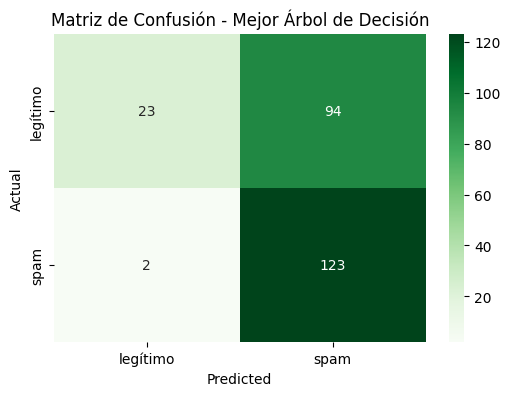

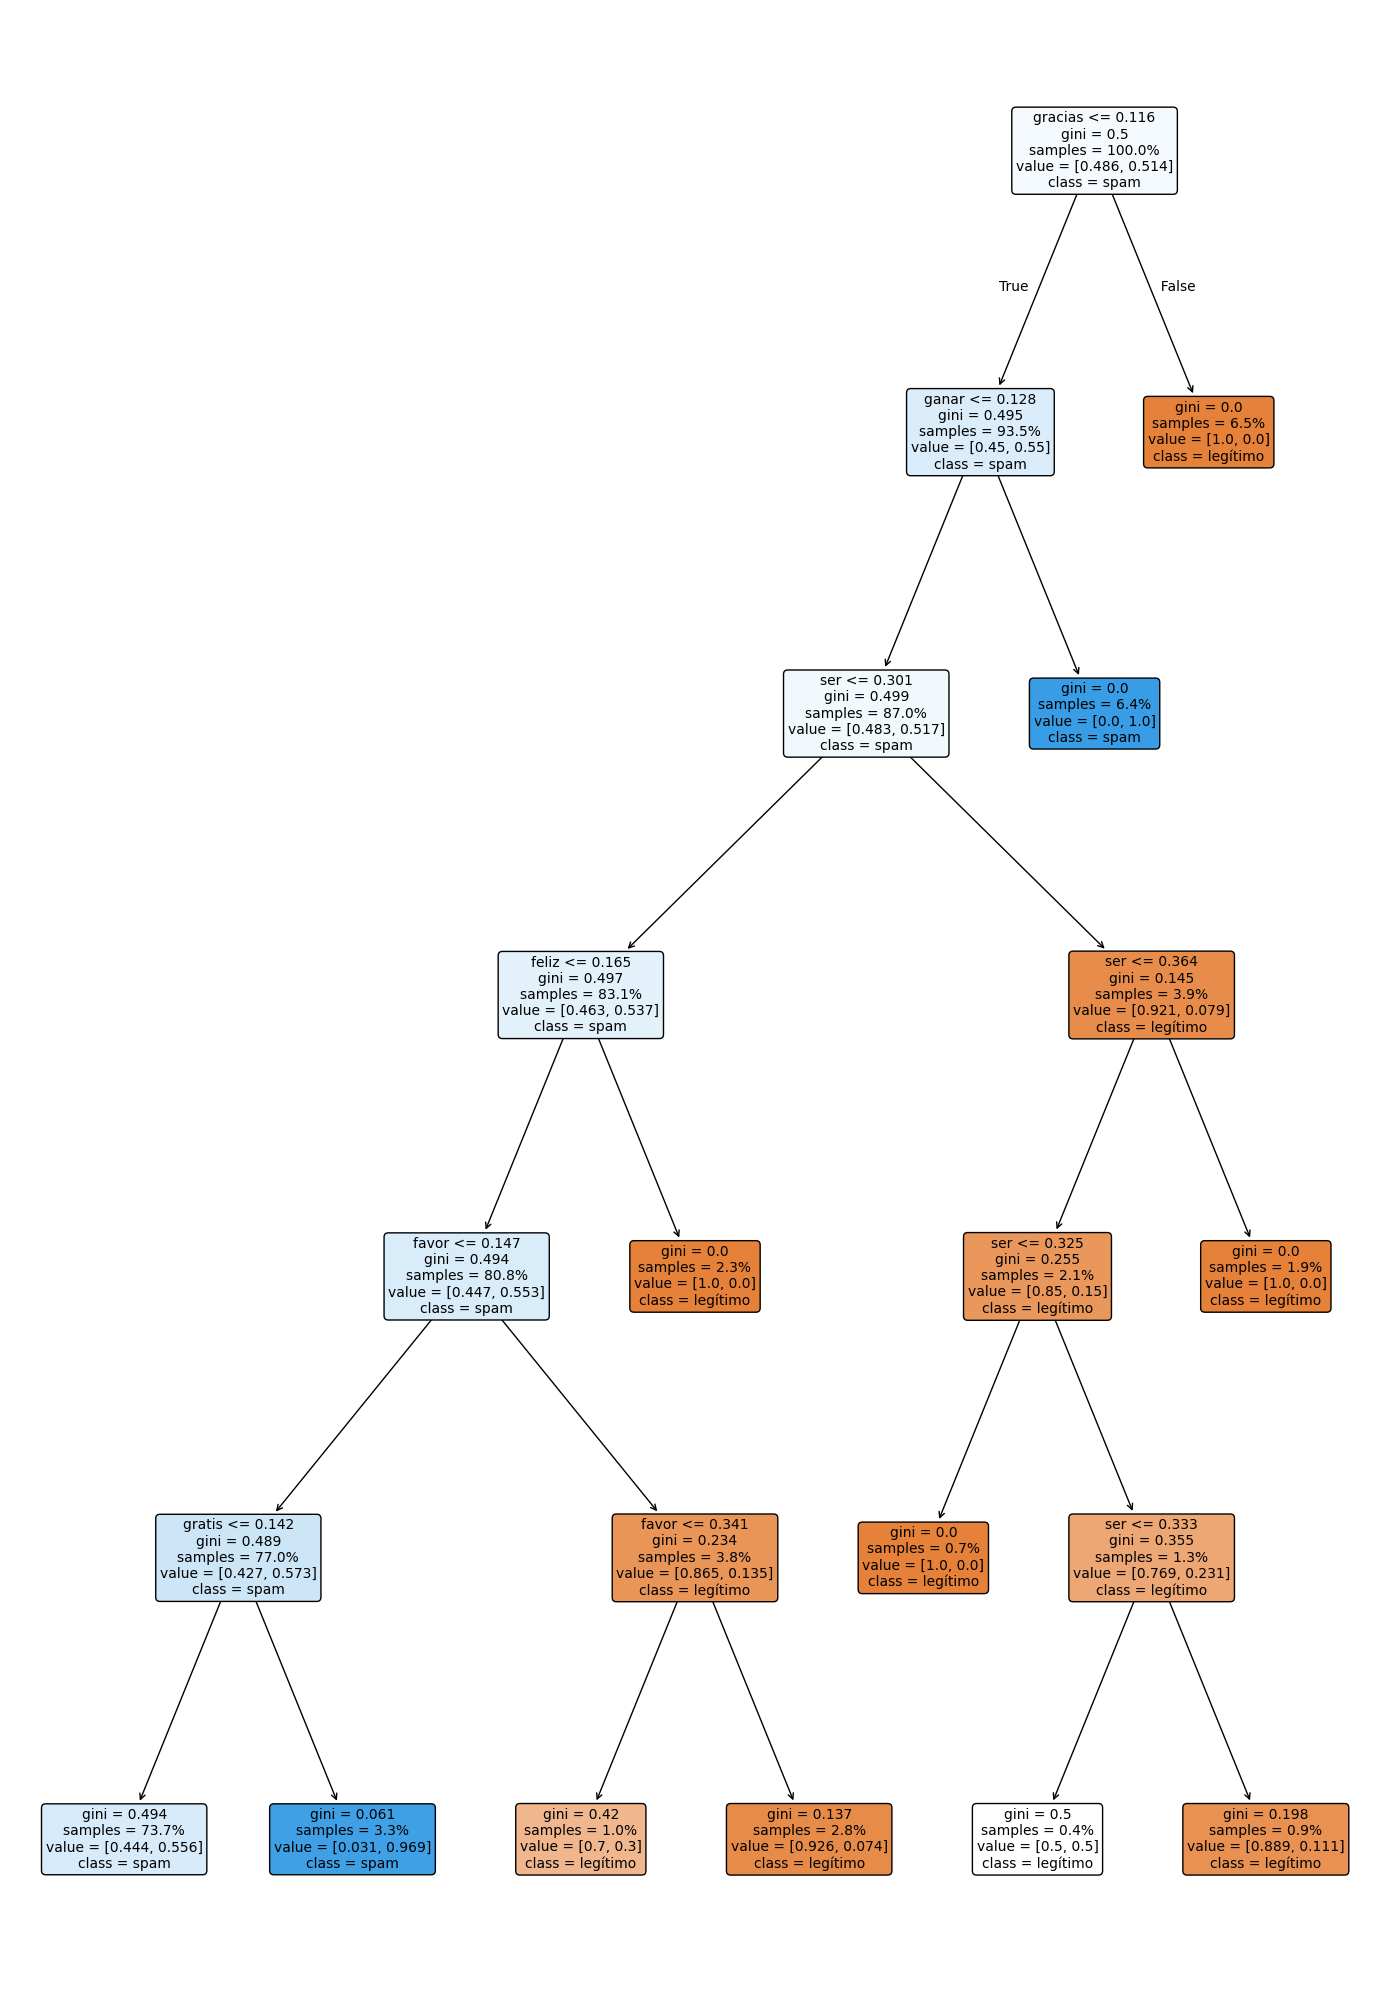

In [17]:
print ("\nResultados completos del Grid Search:")

# Nos quedamos con el mejor modelo encontrado
best_decision_tree_model = decission_tree_grid.best_estimator_

# Entrenamos el mejor modelo con todo el conjunto de entrenamiento
best_decision_tree_model.fit(
    train_documentos_procesados,
    train_df['tipo']
)

# Ejecutamos todas las predicciones sobre el conjunto de test.
best_decison_tree_predictions = best_decision_tree_model.predict(test_documentos_procesados)

# Evaluamos el rendimiento del mejor modelo encontrado
best_accuracy = accuracy_score(test_df['tipo'], best_decison_tree_predictions)
best_precision = precision_score(test_df['tipo'], best_decison_tree_predictions, pos_label='spam')
best_recall = recall_score(test_df['tipo'], best_decison_tree_predictions, pos_label='spam')
best_f1 = f1_score(test_df['tipo'], best_decison_tree_predictions, pos_label='spam')
print("\nEvaluación del mejor modelo en el conjunto de test:")
print(f"Exactitud (Accuracy): {best_accuracy:.4f}")
print(f"Precisión (Precision): {best_precision:.4f}")
print(f"Exhaustividad (Recall): {best_recall:.4f}")
print(f"Puntuación F1 (F1 Score): {best_f1:.4f}")
print("\nReporte de clasificación del mejor modelo:")
print(classification_report(test_df['tipo'], best_decison_tree_predictions))

# Muestra la matriz de confusión del mejor modelo
best_conf_matrix = confusion_matrix(test_df['tipo'], best_decison_tree_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(best_conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - Mejor Árbol de Decisión')
plt.show()

# Muestra el árbol de decisión entrenado de manera gráfica
plt.figure(figsize=(14,20))
plot_tree(
    best_decision_tree_model.named_steps['classifier'],                                          # El clasificador del pipeline
    feature_names= best_decision_tree_model.named_steps['vectorizer'].get_feature_names_out(),   # lista de nombres de features
    class_names= best_decision_tree_model.named_steps['classifier'].classes_,                    # lista de nombres de clases
    filled=True,                   # colorea según la clase mayoritaria
    rounded=True,
    proportion=True,               # usa proporciones (en vez de conteos)
    fontsize=10
)
plt.tight_layout()
plt.show()

### Cómo funcionaría una predicción con un árbol ya entrenado

El proceso de la ejecución de una predicción de ejemplo podría ser algo así:

- Dado el texto original: "Gana musculos rapidamente con este suplemento"
- Lo pre-procesamos (tras tokenización, eliminación de stopwords y lematización): "ganar musculo rapidamente suplemento"
- Su Etiqueta real es : **spam**
- La Etiqueta predicha por el árbol ha sido: **spam**

El árbol habría llegado a esa predicción siguiendo esta secuencia de pasos:

1. **Paso 1:** El árbol consulta la característica correspondiente a la palabra **"gracias"**. El valor TF‑IDF de esa característica en el documento de prueba es 0.000, y el umbral en ese nodo era 0.116. Como el valor es menor o igual al umbral, el árbol toma la rama izquierda.

2. **Paso 2:** En el siguiente nodo el árbol evalúa la característica **"ganar"**. El valor TF‑IDF para esta palabra en el documento de prueba es 0.371 y el umbral es 0.128. Como el valor es mayor que el umbral, el árbol toma la rama derecha.

3. **Nodo hoja alcanzado:** Tras esas decisiones el árbol llega a una hoja que, en el conjunto de entrenamiento mostrado, contiene el 100% de los ejemplos etiquetados como **spam** (proporción en la hoja: 1.0 spam / 0.0 legítimo). Por tanto, la predicción final es **"spam"**.

Interpretación práctica: El modelo ha basado su decisión en la ausencia de la palabra "gracias" y en la fuerte presencia (TF‑IDF alta) de la palabra "ganar". Estas reglas llevan a un nodo hoja con predominio absoluto de ejemplos spam, por lo que la predicción es coherente con la etiqueta real.

### Observabilidad del árbol
En esta sección vamos a ver algunos mecanismos que nos permiten examinar _de carca_ el árbol y las predicciones que ha hecho.
Para ello ...

Vamos a trabajar con una muestra seleccionada al azar de nuestro conjunto original de tests. Realizaremos la predicción con el modelo entrenado con los mejores parámetros que se han conseguido por medio de ´GridSearchCV` y observaremos distintas visualizaciones interesantes para ver qué es lo que ha hecho el árbol para tomar sus decisiones.

In [18]:
# Selecciona al azar un documento del conjunto de test.
random_idx = random.randint(0, len(test_documentos_procesados) - 1)
documento_azar = test_documentos_procesados[random_idx]
etiqueta_real_azar = test_df['tipo'].iloc[random_idx]

print(f"Documento seleccionado al azar (índice {random_idx}):")
print(f"Texto original: {test_df['mensaje'].iloc[random_idx]}")
print(f"Texto preprocesado: {documento_azar}")

# Realiza la predicción con el mejor modelo que hemos encontrado con el GridSearchCV.
etiqueta_predicha_azar = best_decision_tree_model.predict([documento_azar])[0]

# Muestra el resultado de la predicción.
print(f"Etiqueta real: {etiqueta_real_azar}")
print(f"Etiqueta predicha: {etiqueta_predicha_azar}")

print (
    export_text (
        best_decision_tree_model.named_steps['classifier'], 
        feature_names= best_decision_tree_model.named_steps['vectorizer'].get_feature_names_out().tolist(),
        decimals= 3,        # Número de decimales para mostrar los valores de umbral
        max_depth= 50,      # Profundidad máxima del árbol a mostrar
        spacing= 3,         # Espaciado entre niveles del árbol
        show_weights= True  # Muestra los pesos de las clases en las hojas
    )
)

# Describe en leguaje natural cómo se realiza la predicción para el documento seleccionado al azar que hemos preprocesado antes.


Documento seleccionado al azar (índice 154):
Texto original: Registra tu telefono en un clic
Texto preprocesado: registrar telefono clic
Etiqueta real: legítimo
Etiqueta predicha: spam
|--- gracias <= 0.116
|   |--- ganar <= 0.128
|   |   |--- ser <= 0.301
|   |   |   |--- feliz <= 0.165
|   |   |   |   |--- favor <= 0.147
|   |   |   |   |   |--- gratis <= 0.142
|   |   |   |   |   |   |--- weights: [316.000, 395.000] class: spam
|   |   |   |   |   |--- gratis >  0.142
|   |   |   |   |   |   |--- weights: [1.000, 31.000] class: spam
|   |   |   |   |--- favor >  0.147
|   |   |   |   |   |--- favor <= 0.341
|   |   |   |   |   |   |--- weights: [7.000, 3.000] class: legítimo
|   |   |   |   |   |--- favor >  0.341
|   |   |   |   |   |   |--- weights: [25.000, 2.000] class: legítimo
|   |   |   |--- feliz >  0.165
|   |   |   |   |--- weights: [22.000, 0.000] class: legítimo
|   |   |--- ser >  0.301
|   |   |   |--- ser <= 0.364
|   |   |   |   |--- ser <= 0.325
|   |   |   |   |  

In [19]:
# Función para rastrear el camino en el árbol de decisión
def rastrear_camino_arbol(arbol, caracteristicas, muestra):
    nodo = 0  # Comenzamos en la raíz del árbol
    camino = []
    while arbol.children_left[nodo] != arbol.children_right[nodo]:  # Mientras no sea un nodo hoja
        caracteristica_idx = arbol.feature[nodo]
        umbral = arbol.threshold[nodo]
        valor_muestra = muestra[0, caracteristica_idx]
        if valor_muestra <= umbral:
            camino.append((nodo, 'izquierda', caracteristica_idx, umbral, valor_muestra))
            nodo = arbol.children_left[nodo]
        else:
            camino.append((nodo, 'derecha', caracteristica_idx, umbral, valor_muestra))
            nodo = arbol.children_right[nodo]
    camino.append((nodo, 'hoja', None, None, None))  # Nodo hoja
    return camino

# Obtener el árbol de decisión del pipeline
arbol_decision = best_decision_tree_model.named_steps['classifier'].tree_

# Vectorizar el documento de azar
vectorizador = decission_tree_pipeline.named_steps['vectorizer']

documento_vectorizado = vectorizador.transform([documento_azar]).toarray()

# Rastrear el camino en el árbol
camino = rastrear_camino_arbol(arbol_decision, vectorizador.get_feature_names_out(), documento_vectorizado)

# Mostrar el camino seguido
print("\nCamino seguido en el árbol de decisión:")
for paso in camino:
    nodo, direccion, caracteristica_idx, umbral, valor_muestra = paso
    if direccion == 'hoja':
        print(f" Nodo {nodo}: Nodo hoja alcanzado.")
    else:
        caracteristica_nombre = vectorizador.get_feature_names_out()[caracteristica_idx]
        print(f" Nodo {nodo}: Ir a la {direccion} si '{caracteristica_nombre}' (valor: {valor_muestra:.4f}) <= {umbral:.4f}")


Camino seguido en el árbol de decisión:
 Nodo 0: Ir a la izquierda si 'gracias' (valor: 0.0000) <= 0.1160
 Nodo 1: Ir a la izquierda si 'ganar' (valor: 0.0000) <= 0.1282
 Nodo 3: Ir a la izquierda si 'ser' (valor: 0.0000) <= 0.3005
 Nodo 5: Ir a la izquierda si 'feliz' (valor: 0.0000) <= 0.1645
 Nodo 7: Ir a la izquierda si 'favor' (valor: 0.0000) <= 0.1473
 Nodo 9: Ir a la izquierda si 'gratis' (valor: 0.0000) <= 0.1424
 Nodo 11: Nodo hoja alcanzado.


## Implementación de un Random Forest

Para esta implementación utilizaremos el componente `RandomForestClassifier` de la librería SciKit-Learn.

### Entrenamiento del Random Forest

Sus hiper-parámetros más interesantes son los siguientes:

- `n_estimators` (Integer. Defecto= 100): Indica el número de árboles que compondrán el bosque.

- `bootstrap` (Boolean. Defecto= True): Controla la forma en que se generan los subconjuntos de datos que cada árbol del bosque utiliza para entrenarse:
    - True: Se crea un _bootstrap sample_ (muestreo con reemplazo). Cada árbol recibe una muestra aleatoria de n elementos, donde algunos pueden repetirse y otros pueden quedar fuera.
    - False: Se utiliazan todos los datos para entrenar cada árbol.

- `criterion` (String. Defecto=gini): Función utilizada para la medición de la _pureza_ de las diferentes divisionies. Controla la calidad de las divisiones. Sus posibles valores son los siguientes:
    - **gini**: Índice de Gini $G = 1 - \sum_{i=1}^{K} (p_i)^2$
    - **entropy**: Medida de la Entropía (Shannon) $E = -\sum_{i=1}^{K} p_i \log_2(p_i)$
    - **log_loss**: Medida de la Entropía Cruzada $\text{LogLoss} = -\sum_{i} \sum_{c \in C} y_{ic} \log(p_{ic})$. 

- `max_depth` (Integer. Defecto= None): Máxima profundidad que podrá tener el árbol. Si se deja el valor por defecto `None` el átbol expandirá sus nodos hasta que todas las hojas sean puras o contengan menos elementos que los especificados en el parámetro `min_samples_split`.

- `min_samples_split`(Integer. Defecto= 2): Indica el número mínimo de elementos que debe tener un nodo para que pueda ser dividido. Es decir, si un nodo tiene menos de este valor entonces el nodo no se puede dividir más y se convierte en una hoja del árbol.

- `min_samples_leaf` (Integer: Defecto= 1): Indica el mínimo número de elementos que debe tener un nodo para ser considerado como una hoja del árbol. Cuando se hace una división en el árbol esta se podrá realizar si deja al meno este número de elementos tanto en su nodo derecho como izquierdo.

- `max_leaf_nodes` (Integer. Defecto= None): Establece el número máximo de hojas que puede tener el árbol. Es importante recordar en este punto que un nodo hoja es aquel que ya no se va a dividir más pero más importante de todo **son aquellos que emiten la predicción**. Se trata de un método de poda controlada (pre-prunning) del árbol.

- `min_impurity_decrease` (Float. Defecto= 0): Establece cuánta mejora mínima en la pureza debe lograrse para que se realice una divisón dependiendo del `criterion` elegido. Un nodo no se dividirá si no consigue mejorar la pureza al menos en ese valor. También se considera como un argumento para la poda temprana (pre-prunning) del árbol.

- `max_features`: Controla cuántas características (variables) se consideran al buscar la mejor división en cada nodo de un árbol de decisión. Se trata, esencialmente, de una forma de introducir aleatoriedad y reducir el sobreajuste (_overfitting_) del árbol. Puede tomar los siguientes valores:
    - Si especificamos un **número entero**: Utilizará exactamente ese número de características.
    - Si especificamos un **Float** ( 0 <= float <= 1): Utilizará una proporción del número de careterísticas.
    - **Otros** valores:
        - **sqrt**: Raiz cuadrada del número de características.
        - **log2**: Log2 del número de características.
        - **all**: Utilizará todas las características disponibles.

- `ccp_alpha` (Float no negativo. Defecto= 0): Parámetro que controla la _Poda por Complejidad de Coste (CCP)_. El objetivo de la poda es evitar que el árbol crezca demasiado, lo cual puede llevar a un sobreajuste (overfitting). En lugar de limitar el tamaño del árbol con parámetros tradicionales (max_depth, min_samples_split, etc.), ccp_alpha **penaliza explícitamente la complejidad del modelo**.

**NOTAS**
- El componente `RandomForestClassifier`no proporciona un parámetro `splitter`. Internamente, `RandomForestClassifier` llama a `DecisionTreeClassifier` con el parámetro `splitter="best"` (o el valor por defecto).

**CRITERIOS PARA LA ELECCIÓN DEL PARÁMETRO `n_estimators`**
- Cuanto mayor sea el número de árboles que compnen el bosque obetendremos una mayor generalización pero aumentaremos el coste computacional.

Algunos valores de referencia:

| Rango   | Observación típica                                                                                                             |
| ------- | ------------------------------------------------------------------------------------------------------------------------------ |
| 10–50   | Muy rápido, pero perdemos generaliación. Suele ser insuficiente cuando los datos son complejos.                                |
| 100–200 | Buen punto de partida; la mejora en precisión tiende a estabilizarse después de ~150‑200 árboles.                              |
| > 200   | Mejora marginal; el tiempo crece linealmente.                                                                                  |
| 500+    | Útil para conjuntos muy grandes o cuando se necesita una precisión extremadamente alta, pero requiere recursos significativos. |


**CRITERIOS PARA LA ELECCIÓN DEL PARÁMETRO `bootstrap`**
- Si True: Introduce la variabilidad buscada en la construcción de cada uno de los árboles.
- Si False: Los árboles que componen el bosque con más parecidos entre sí.

**CRITERIOS DE SELECCIÓN DEL PARÁMETRO `criterion`**
- Ambas medidas tienen el mismo comportamiento externo. Esto es: 0 cuando un nodo es puro yMáximo cuando las clases se encuentran perfectamente balanceadas.
- La Entropía penaliza más fuerte las distribuciones mixtas, esto es, cuando hay igual número de elementos por cada clase (máxima entropía)
- Gini es computacionalmente más ligero al no tener que calcular logaritmos.
- Cualquiera de los índices es bueno y proporciona resultados similares.
- La Medida de la Entropía Cruzada no la hemos visto en clase dentro de los modelos de Árboles de Decisión pero sí en el caso de la Regresión Logística. También se puede aplicar en árboles y lo que hace, intuitivamente, es **penalizar más aquellas prediccciones que se han realizado de manera incorrecta pero con mucha confianza**.

**CRITERIOS DE AJUSTE PARA EL PARÁMETRO `splitter`**
- **best**: Es mucho más preciso pero mucho más lento ya que explora todas las características en busca de la mejor combinación.
- **random**: Mucho más rápido pero también mucho más impreciso. Introduce aleatoriedad y esto puede resultar conveniente en casos en los que haya que reducir el _overfitting_ del modelo.

**CRITERIOS DE AJUSTE PARA EL PARÁMETRO `max_leaf_nodes`**
- Un árbol con muchas hojas puede padecer de _overfitting_.
- Un árbol con pocas hojas es mucho más simple y generaliza mejor pero puede sufrir de _underfitting_.
- Si dejamos que el árbol crezca hasta sin límite (valor `None`) tendremos un modelo muy complejo.

**CRITERIOS DE AJUSTE PARA EL PARÁMETRO `min_impurity_decrease`**
Algunos valores típicos son los siguientes:

| Valor típico        | Efecto                            | Resultado                                              |
| ------------------- | --------------------------------- | ------------------------------------------------------ |
| `0.0` (por defecto) | Cualquier mejora permite dividir  | Árbol puede crecer muy grande. Riesgo de _overfitting_ |
| `0.01`              | Solo divisiones con mejora ≥ 0.01 | Menos divisiones, árbol más general                    |
| `0.1`               | Muy exigente                      | Árbol pequeño. Riesgo de _underfitting_                |

**CRITERIOS PARA LA ELECCIÓN DEL PARÁMETRO ` max_features`**
- Un punto de partida inicial bueno suele ser utilizar `sqrt`.

**RECORDATORIO SOBRE LA PODA**
Para cada nodo $t$ del árbol se define:
$$R(t) = \text{error}(t)$$

- **Error**: en clasificación suele ser el número de muestras mal clasificadas dentro del nodo (o la pérdida de Gini/entropía).  
- $\alpha$: es el parámetro que controla la penalización.

El criterio que se minimiza para decidir si un nodo debe mantenerse o eliminarse es:
$$R_{\alpha}(t) = R(t) + \alpha \times n_{\text{leaves}}(t)$$
Donde:
- $n_{\text{leaves}}(t)$: número de hojas (sub‑árboles) que están bajo el nodo $t$.
- El término $\alpha \times n_{\text{leaves}}$ penaliza la complejidad: cuanto mayor sea $\alpha$ , más se penalizan los sub‑árboles.

A continuación algunos consejos para la elección del parámetro de ajuste de poda $\alpha$

| Puntos a tener en cuenta | Consejos |
|---------------------------|----------|
| **α muy pequeño** | El árbol casi no se poda; puede sobreajustarse. |
| **α muy grande** | El árbol queda con pocas hojas, quizá sub‑ajustado. |

Para más información se recomienda visitar la [página con la documentación oficial de SciKit-Learn relativa all componente `RandomForestClassifier'](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [20]:
# Crear y entrenar el modelo de Random Forest
random_forest = RandomForestClassifier (
    n_estimators= 100,              # Número de árboles en el bosque
    criterion= 'gini',              # Criterio de división de nodos.
    max_features= 'sqrt',           # Número de características a considerar en cada división.
    max_depth= None,                # Profundidad máxima del árbol.
    min_samples_split =4,           # Mínimo de muestras para dividir un nodo.
    min_samples_leaf= 2,            # Mínimo de muestras en una hoja.
    min_impurity_decrease= 0.01,    # Mínima disminución de impureza para dividir un nodo.
    class_weight= 'balanced',       # Manejo del desbalanceo de clases.
    random_state= RANDOM_SEED       # Semilla para la reproducibilidad.
)

random_forest_pipeline = Pipeline(
    steps= [
        ('vectorizer', tfidf_vectorizer),
        ('classifier', random_forest)
    ]
)
random_forest_pipeline.fit(
    train_documentos_procesados,
    train_df['tipo']
)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### Pruebas sobre el conjunto de test inicial
Vamos a realizar una prediccón inicial por medio del conjunto de test que hemos obtenido anteriormente del dataset general.
Con esto nos podemos hacer una primera idea de lo bien que se desempeña el modelo con los parámetros de entrenamiento que le hemos proporcionado inicialmente.

Número de documentos de test procesados: 242
Documentos de test procesados: ['reconfirma correo evitar suspensión', 'ganar gift card tiendo favorita', 'lamentar informarte postulación ser seleccionar']...

Evaluación del modelo de Regresión Logística en el conjunto de test:
Exactitud (Accuracy): 0.6033
Precisión (Precision): 0.5674
Exhaustividad (Recall): 0.9760
Puntuación F1 (F1 Score): 0.7176

Reporte de clasificación:
              precision    recall  f1-score   support

    legítimo       0.89      0.21      0.33       117
        spam       0.57      0.98      0.72       125

    accuracy                           0.60       242
   macro avg       0.73      0.59      0.53       242
weighted avg       0.72      0.60      0.53       242



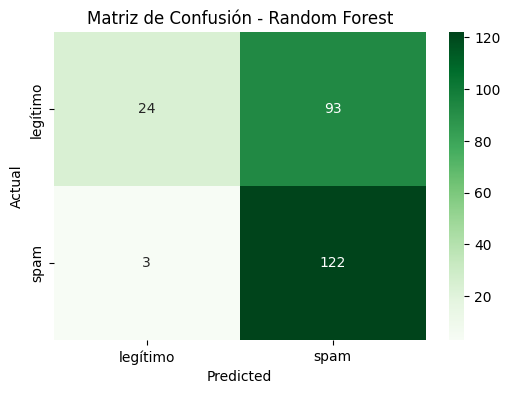

Número de fallos en las predicciones: 96


,mensaje,tipo,predicted
287,Lamentamos informarte que tu postulación no ha...,legítimo,spam
131,Este es un aviso de tu banco,legítimo,spam
539,Hemos extendido tu garantía sin costo adicional,legítimo,spam
905,Felicidades tu crédito fue pre-aprobado,legítimo,spam
1126,Construyamos juntos un mundo mejor,legítimo,spam
...,...,...,...
940,Comunicado: cambio temporal de sede,legítimo,spam
667,Actualiza tu método de pago,legítimo,spam
595,Bienvenido a nuestro selecto club,legítimo,spam
420,Hola ¿te gustaría colaborar en nuestro proyecto?,legítimo,spam


In [21]:
# Preprocesamos los documentos del conjunto de test
test_documentos_procesados = []
for i, doc in enumerate(test_df['mensaje']):
    tokens = preprocesar_documento(doc)
    test_documentos_procesados.append(" ".join(tokens)) 
# Número de documentos de test procesados
print(f"Número de documentos de test procesados: {len(test_documentos_procesados)}")
print(f"Documentos de test procesados: {test_documentos_procesados[:3]}...")  # Muestra los primeros 3 documentos procesados

# Realiza las predicciones utilizando el pipeline de Random Forest
rf_predictions = random_forest_pipeline.predict(test_documentos_procesados)

accuracy = accuracy_score(test_df['tipo'], rf_predictions)
precision = precision_score(test_df['tipo'], rf_predictions, pos_label='spam')
recall = recall_score(test_df['tipo'], rf_predictions, pos_label='spam')
f1 = f1_score(test_df['tipo'], rf_predictions, pos_label='spam')

print("\nEvaluación del modelo de Regresión Logística en el conjunto de test:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Exhaustividad (Recall): {recall:.4f}")
print(f"Puntuación F1 (F1 Score): {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(test_df['tipo'], rf_predictions))

# Muestra la matriz de confusión
conf_matrix = confusion_matrix(test_df['tipo'], rf_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# Saca los documentos que han fallado y la etiqueta real y la predicha
fallos = test_df[test_df['tipo'] != rf_predictions]
print(f"Número de fallos en las predicciones: {fallos.shape[0]}")
display(fallos.assign(predicted= rf_predictions[test_df['tipo'] != rf_predictions]))

### Validación Cruzada
La **validación cruzada** (cross‑validation) es una técnica de evaluación que permite estimar con mayor confianza el rendimiento de un modelo cuando se dispone de un conjunto limitado de datos.  

En lugar de dividir los datos en solo *train* y *test*, el algoritmo repite la partición varias veces, entrenando el modelo sobre distintas “folds” (subconjuntos) y evaluándolo sobre las restantes. El resultado final suele ser la media (y a veces la desviación estándar) de todas esas iteraciones.

Para realizar una validación cruzada en SciKit-Learn utilizaremos el componente `StratifiedKFold` para definir la configuración del proceso cross-validation que queremos realizar.

Los parámetros que acepta el componente `StratifiedKFold` son los siguientes:

- `n-splits` (Integer. Defecto= 5): Número de particiones que deseamos realizar sobre el conjunto de datos de entrenamiento para realizar el proceso de validación cruzada.
- `shuffle` (Boolean. Defecto= False): Si es True, se barajan los datos antes de crear las particiones. Es útil cuando la distribución de clases no está balanceada en el dataset original.
- `random_state` (Integer): Fija un valor de reproducibilidad del experimento.

Para realizar el proceso llamaremos a la función `cross_val_score` cuyos parmetros son los siguientes:

- `estimator`: El objeto que hemos utilizado para realizar el `fit` del modelo. En nuestro caso es el pipeline que hemos configurado anteriormente con el vectorizador tf-idf y el clasificador por Regresión Logística.
- `X`: datos preprocesados de entrenamientos.
- `y`: Clases utilizadas en el entrenamiento.
- `cv`: El Cross Validator que le pasamos con la configuración que tiene que utilizar para realizar la operacion de validación cruzada
- `scoring` (String accuracy | f1 | ...): Métrica a utilizar para evaluar el desempeño del modelo. Se pueden consultar las diferentes métricas que se pueden indicar en el [siguiente enlace](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names).

**Ventajas de realizar un proceso de validación cruzada**
- **Reducción del sesgo**: No dependemos de una sola partición aleatoria.
- **Uso eficiente de los datos**: Cada partición se utiliza tanto para entrenamiento como para prueba.
- **Información de variabilidad**: Permite ver cómo varía el rendimiento entre distintas particiones.

Para más información se recomienda visitar las siguientes páginas:
- [Página de la documentación oficial de SciKit-Learn correspondiente al componente StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)]
- [Documentación oficial sobre la función cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)

In [22]:
# Configuramos el cross validator estratificado
cross_validator = StratifiedKFold (
    n_splits= 15,                               # Número de folds
    shuffle= True,                              # Mezcla los datos antes de dividir
    random_state= RANDOM_SEED                   # Semilla para reproducibilidad
)

# Realiza la validación cruzada...
scores = cross_val_score(
    estimator= random_forest_pipeline,         # Pipeline de Regresión Logística
    X= train_documentos_procesados,             # Documentos de entrenamiento preprocesados
    y= train_df['tipo'],                        # Etiquetas (clases) de entrenamiento
    cv=cross_validator,                         # Validador cruzado estratificado 
    scoring='accuracy'                          # Métrica de evaluación
)

# Muestra los resultados de la validación cruzada
print("Resultados de la validación cruzada (accuracy) en el conjunto de entrenamiento:")
for fold_idx, score in enumerate(scores):
    print(f" Fold {fold_idx + 1}: {score:.4f}")

print(f" Precisión media: {scores.mean():.4f} ± {scores.std():.4f}")

Resultados de la validación cruzada (accuracy) en el conjunto de entrenamiento:
 Fold 1: 0.6615
 Fold 2: 0.6615
 Fold 3: 0.6462
 Fold 4: 0.6769
 Fold 5: 0.6154
 Fold 6: 0.6094
 Fold 7: 0.7344
 Fold 8: 0.7500
 Fold 9: 0.7500
 Fold 10: 0.6094
 Fold 11: 0.6719
 Fold 12: 0.5938
 Fold 13: 0.6875
 Fold 14: 0.6094
 Fold 15: 0.6562
 Precisión media: 0.6622 ± 0.0497


### Búsqueda de los mejores Hiper-Parámetros de Entrenamiento con `GridSearchCV`
Como vemos, uno de los trabajos mas importantes a la hora de generar un buen modelo reside en la correcta elección de los hiper parámetros que se le especifican al modelo en el momento de su entrenamiento.

Esto puede resulta una tarea de prueba/error bastante tediosa. Para facilitarnos la tarea existe la clase `GridSearchCV`en SciKit-Learn.

Este componente realiza varias ejecuciones del modelo con diferentes combinaciones de valores de los hiperparámetros definidos en un diccionario, y evalúa el rendimiento del modelo utilizando una métrica de validación cruzada (cross-validation). En otras palabras, automatiza el proceso de búsqueda de los mejores hiper parametros identificando la combinación óptima de los mismos que maximiza el desempeño del modelo.

**Parámetros importantes de la clase `GridSearchCV`**
- `estimator`: Esta es la instancia del componente `DecisionTreeClassifier` que hemos instanciado.
- `param-grid`: Diccionario con los nombres de los hiper-parámetros a ajustar y los diferentes valores para cada uno de ellos que queremos probar.
- `scoring`: Estrategias métricas a evaluar del modelo (accuracy, f1, etc.). Consultar la [siguiente tabla](https://scikit-learn.org/stable/modules/model_evaluation.html#string-name-scorers) para ver los posibles valores que se pueden especificar en este parámetro.
- `n-jobs` (Integer. Defecto: None): Número de hilos de ejecución o trabajos en paralelo que se lanzan. Si se especifica -1 se utilizarán todos los procesadores de la máquina para realizar la validación cruzada y la mejor estimación de los hiper-parámetros especificados.
- `cv` (Integer. Defecto None= 5) Indica el núnero de particiones del dataset de entrenamiento que se harán para la validación cruzada.
- `verbose` (Integer) Controla el nivel de detalle de los mensajes informativos proporcionados durante la ejecución:
    - Mayor que 1: Se muestra el tiempo de proceso y el parámetro candidato.
    - Mayor que 2: Se incluye además el _scoring_.
    - Mayor que 3: Se incluye la partición.

Para más información se recomienda visitar las siguientes páginas de la documentación oficial del componente `GridSearchCV`
- [Documentación oficial del componente GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [Cross-Validation: Evaluating Estimator Performance](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Tunning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)

In [23]:
# Especificamos los HiperParámetros a evaluar en el GridSearchCV
random_forest_param_grid = {
    # Hiper-Parámetros del TfidfVectorizer
    # 'vectorizer__ngram_range': [(1,1), (1,2)],
    # 'vectorizer__max_df': [0.75, 0.85, 1.0],
    # 'vectorizer__min_df': [1, 2, 5],
    # 'vectorizer__max_features': [None, 10000, 30000],
# 
    # Hiper-Parámetros del RandomForest
    'classifier__n_estimators': [100, 300, 700, 800, 900, 1000],
    'classifier__criterion': ['gini', 'entropy'],
    # 'classifier__max_depth': [None, 20, 50, 100],
    'classifier__max_depth': [20, 50, 100, 150, 200, 250],
    # 'classifier__min_samples_split': [2, 4, 8],
    # 'classifier__min_samples_leaf': [1, 2, 4],
    # 'classifier__max_features': ['sqrt', 'log2', None],  # o floats 0.3, 0.5 si quieres
    # 'classifier__class_weight': [None, 'balanced', 'balanced_subsample']
}

cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_SEED)

# Configurar GridSearchCV
random_forest_grid = GridSearchCV (
    estimator= random_forest_pipeline,              # Pipeline para la SVM implementada con SGD.
    param_grid= random_forest_param_grid,           # HiperParámetros a ajustar.
    cv= 10,                                         # Número de folds a utilizar en el proceso interno de validación cruzada.
    scoring= 'accuracy',                            # Métrica de evaluación.
    n_jobs= -1,                                     # Paraleliza en todos los cores disponibles en la máquina.
    refit= True,                                    # Reajusta el mejor modelo con todo el conjunto de entrenamiento.
    verbose= 5                                      # Nivel de detalle de la salida.
)

# Ejecuta el ajuste del modelo con el GridSearchCV
start_time= pd.Timestamp.now()
random_forest_grid.fit (    
    train_documentos_procesados, 
    train_df['tipo']
)
# Muestra el tiempo de ejecución en segundos
end_time= pd.Timestamp.now()
print(f"Tiempo de ejecución del GridSearchCV: {(end_time - start_time).total_seconds()} segundos")

# Podemos obtener una visión general de los resultados del GridSearchCV en forma de DataFrame para su análisis
# gridsearch_Results= pd.DataFrame (logreg_grid.cv_results_)
# display (gridsearch_Results.sort_values (by= 'mean_test_score', ascending= False))

print("Mejores hiper-parámetros encontrados:")
best_parms= pd.Series (random_forest_grid.best_params_)
display(best_parms)

print(f"Mejor puntuación de validación cruzada: {random_forest_grid.best_score_:.4f}")

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Tiempo de ejecución del GridSearchCV: 147.558626 segundos
Mejores hiper-parámetros encontrados:


classifier__criterion       entropy
classifier__max_depth            20
classifier__n_estimators        800
dtype: object

Mejor puntuación de validación cruzada: 0.8134


Nos quedamos con la mejor predicción para los hiper parámetros que hemos elegido y ejecutamos un test general del nuevo clasificador "mejorado" contra el conjunto de tests original.


Resultados completos del Grid Search:

Evaluación del mejor modelo en el conjunto de test:
Exactitud (Accuracy): 0.7397
Precisión (Precision): 0.6962
Exhaustividad (Recall): 0.8800
Puntuación F1 (F1 Score): 0.7774

Reporte de clasificación del mejor modelo:
              precision    recall  f1-score   support

    legítimo       0.82      0.59      0.69       117
        spam       0.70      0.88      0.78       125

    accuracy                           0.74       242
   macro avg       0.76      0.73      0.73       242
weighted avg       0.76      0.74      0.73       242



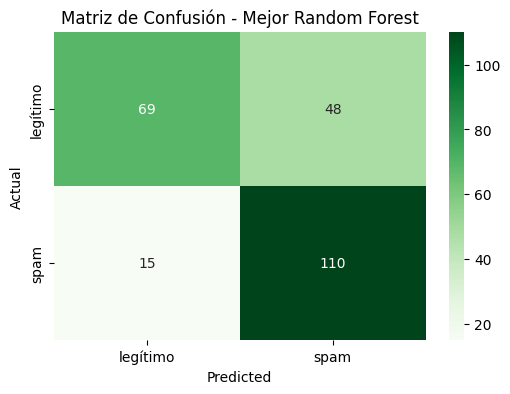

In [24]:
print ("\nResultados completos del Grid Search:")

# Nos quedamos con el mejor modelo encontrado
best_random_forest_model = random_forest_grid.best_estimator_

# Entrenamos el mejor modelo con todo el conjunto de entrenamiento
best_random_forest_model.fit(
    train_documentos_procesados,
    train_df['tipo']
)

# Ejecutamos todas las predicciones sobre el conjunto de test.
best_random_forest_predictions = best_random_forest_model.predict(test_documentos_procesados)

# Evaluamos el rendimiento del mejor modelo encontrado
best_accuracy = accuracy_score(test_df['tipo'], best_random_forest_predictions)
best_precision = precision_score(test_df['tipo'], best_random_forest_predictions, pos_label='spam')
best_recall = recall_score(test_df['tipo'], best_random_forest_predictions, pos_label='spam')
best_f1 = f1_score(test_df['tipo'], best_random_forest_predictions, pos_label='spam')
print("\nEvaluación del mejor modelo en el conjunto de test:")
print(f"Exactitud (Accuracy): {best_accuracy:.4f}")
print(f"Precisión (Precision): {best_precision:.4f}")
print(f"Exhaustividad (Recall): {best_recall:.4f}")
print(f"Puntuación F1 (F1 Score): {best_f1:.4f}")
print("\nReporte de clasificación del mejor modelo:")
print(classification_report(test_df['tipo'], best_random_forest_predictions))

# Muestra la matriz de confusión del mejor modelo
best_conf_matrix = confusion_matrix(test_df['tipo'], best_random_forest_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(best_conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - Mejor Random Forest')
plt.show()

# Gradient Boosting

### Exponential loss

In [40]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Crea el vectorizador TF-IDF
tfidf_vectorizer_gbc = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features=None
)

# Crear el modelo de Gradient Boosting
gradient_boosting = GradientBoostingClassifier(
    n_estimators=300,               # Número de árboles en el ensamble secuencial
    learning_rate=0.05,             # Tasa de aprendizaje (shrinkage)
    max_depth=6,                    # Profundidad máxima de cada árbol base
    subsample=0.8,                  # Fracción de muestras para entrenar cada árbol
    random_state=RANDOM_SEED,        # Semilla para la reproducibilidad
    loss= "exponential"
)

# Montamos el pipeline de entrenamiento
gradient_boosting_pipeline = Pipeline(
    steps=[
        ('vectorizer', tfidf_vectorizer_gbc),
        ('classifier', gradient_boosting)
    ]
)

# Entrenamiento
gradient_boosting_pipeline.fit(
    train_documentos_procesados,
    train_df['tipo']
)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None



Evaluación del modelo Gradient Boosting en el conjunto de test:
Exactitud (Accuracy): 0.7934
Precisión (Precision): 0.7551
Exhaustividad (Recall): 0.8880
Puntuación F1 (F1 Score): 0.8162

Reporte de clasificación:
              precision    recall  f1-score   support

    legítimo       0.85      0.69      0.76       117
        spam       0.76      0.89      0.82       125

    accuracy                           0.79       242
   macro avg       0.80      0.79      0.79       242
weighted avg       0.80      0.79      0.79       242



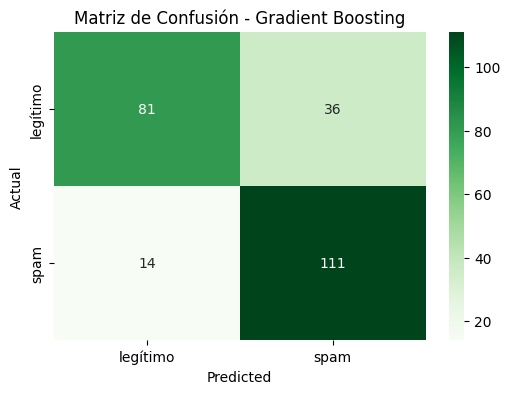

Número de fallos en las predicciones: 50


,mensaje,tipo,predicted
131,Este es un aviso de tu banco,legítimo,spam
539,Hemos extendido tu garantía sin costo adicional,legítimo,spam
642,Salvemos más vidas con tu donación,legítimo,spam
12,Felicidades has ganado un telefono nuevo,spam,legítimo
919,Asiste a la charla motivacional,legítimo,spam
902,Conoce solteros compatibles contigo,spam,legítimo
816,Ayúdanos a superar esta marca mundial,spam,legítimo
497,Hemos recibido tu aplicación te contactaremos ...,legítimo,spam
1074,Brinda esperanza apadrinando un nino,legítimo,spam
909,Tu compra está protegida,legítimo,spam


In [41]:
# Predicciones
gbc_predictions = gradient_boosting_pipeline.predict(test_documentos_procesados)

# Métricas
accuracy = accuracy_score(test_df['tipo'], gbc_predictions)
precision = precision_score(test_df['tipo'], gbc_predictions, pos_label='spam')
recall = recall_score(test_df['tipo'], gbc_predictions, pos_label='spam')
f1 = f1_score(test_df['tipo'], gbc_predictions, pos_label='spam')

print("\nEvaluación del modelo Gradient Boosting en el conjunto de test:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Exhaustividad (Recall): {recall:.4f}")
print(f"Puntuación F1 (F1 Score): {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(test_df['tipo'], gbc_predictions))

# Matriz de confusión
conf_matrix = confusion_matrix(test_df['tipo'], gbc_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - Gradient Boosting')
plt.show()

# Documentos fallados
fallos = test_df[test_df['tipo'] != gbc_predictions]
print(f"Número de fallos en las predicciones: {fallos.shape[0]}")
display(fallos.assign(predicted=gbc_predictions[test_df['tipo'] != gbc_predictions]))

### Log-Loss

In [35]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Crea el vectorizador TF-IDF
tfidf_vectorizer_gbc = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features=None
)

# Crear el modelo de Gradient Boosting
gradient_boosting = GradientBoostingClassifier(
    n_estimators=300,               # Número de árboles en el ensamble secuencial
    learning_rate=0.05,             # Tasa de aprendizaje (shrinkage)
    max_depth=6,                    # Profundidad máxima de cada árbol base
    subsample=0.8,                  # Fracción de muestras para entrenar cada árbol
    random_state=RANDOM_SEED        # Semilla para la reproducibilidad
)

# Montamos el pipeline de entrenamiento
gradient_boosting_pipeline = Pipeline(
    steps=[
        ('vectorizer', tfidf_vectorizer_gbc),
        ('classifier', gradient_boosting)
    ]
)

# Entrenamiento
gradient_boosting_pipeline.fit(
    train_documentos_procesados,
    train_df['tipo']
)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None



Evaluación del modelo Gradient Boosting en el conjunto de test:
Exactitud (Accuracy): 0.8058
Precisión (Precision): 0.7671
Exhaustividad (Recall): 0.8960
Puntuación F1 (F1 Score): 0.8266

Reporte de clasificación:
              precision    recall  f1-score   support

    legítimo       0.86      0.71      0.78       117
        spam       0.77      0.90      0.83       125

    accuracy                           0.81       242
   macro avg       0.82      0.80      0.80       242
weighted avg       0.81      0.81      0.80       242



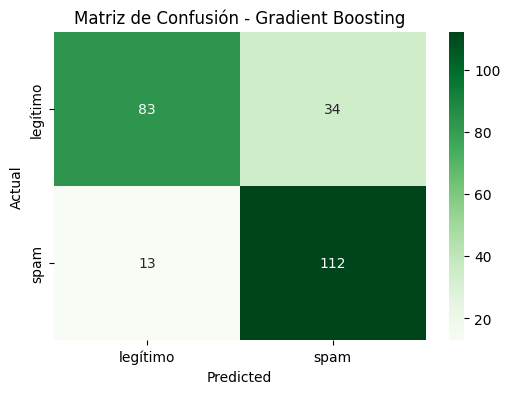

Número de fallos en las predicciones: 47


,mensaje,tipo,predicted
131,Este es un aviso de tu banco,legítimo,spam
539,Hemos extendido tu garantía sin costo adicional,legítimo,spam
642,Salvemos más vidas con tu donación,legítimo,spam
12,Felicidades has ganado un telefono nuevo,spam,legítimo
919,Asiste a la charla motivacional,legítimo,spam
180,Realiza tu pago antes de la fecha limite,legítimo,spam
902,Conoce solteros compatibles contigo,spam,legítimo
816,Ayúdanos a superar esta marca mundial,spam,legítimo
497,Hemos recibido tu aplicación te contactaremos ...,legítimo,spam
1074,Brinda esperanza apadrinando un nino,legítimo,spam


In [37]:
# Predicciones
gbc_predictions = gradient_boosting_pipeline.predict(test_documentos_procesados)

# Métricas
accuracy = accuracy_score(test_df['tipo'], gbc_predictions)
precision = precision_score(test_df['tipo'], gbc_predictions, pos_label='spam')
recall = recall_score(test_df['tipo'], gbc_predictions, pos_label='spam')
f1 = f1_score(test_df['tipo'], gbc_predictions, pos_label='spam')

print("\nEvaluación del modelo Gradient Boosting en el conjunto de test:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Exhaustividad (Recall): {recall:.4f}")
print(f"Puntuación F1 (F1 Score): {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(test_df['tipo'], gbc_predictions))

# Matriz de confusión
conf_matrix = confusion_matrix(test_df['tipo'], gbc_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - Gradient Boosting')
plt.show()

# Documentos fallados
fallos = test_df[test_df['tipo'] != gbc_predictions]
print(f"Número de fallos en las predicciones: {fallos.shape[0]}")
display(fallos.assign(predicted=gbc_predictions[test_df['tipo'] != gbc_predictions]))

In [27]:
!pip install xgboost
!pip install lightgbm


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# XGBoost

In [28]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Mapeo a valores binarios (0 = legítimo, 1 = spam) requerido por XGBoost
y_train_num = (train_df['tipo'] == 'spam').astype(int)

# Crea el vectorizador TF-IDF
tfidf_vectorizer_xgb = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features=None
)

# Crear el modelo XGBoost
xgb_classifier = XGBClassifier(
    n_estimators=300,               # Número de árboles
    learning_rate=0.05,             # Paso de reducción
    max_depth=5,                    # Profundidad por árbol
    subsample=0.8,                  # Submuestreo de filas
    colsample_bytree=0.8,           # Submuestreo de características (columnas)
    eval_metric='logloss',          # Función de pérdida a optimizar
    random_state=RANDOM_SEED        # Semilla para la reproducibilidad
)

# Montamos el pipeline de entrenamiento
xgb_pipeline = Pipeline(
    steps=[
        ('vectorizer', tfidf_vectorizer_xgb),
        ('classifier', xgb_classifier)
    ]
)

# Entrenamiento
xgb_pipeline.fit(
    train_documentos_procesados,
    y_train_num
)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None



Evaluación del modelo XGBoost en el conjunto de test:
Exactitud (Accuracy): 0.7314
Precisión (Precision): 0.6807
Exhaustividad (Recall): 0.9040
Puntuación F1 (F1 Score): 0.7766

Reporte de clasificación:
              precision    recall  f1-score   support

    legítimo       0.84      0.55      0.66       117
        spam       0.68      0.90      0.78       125

    accuracy                           0.73       242
   macro avg       0.76      0.73      0.72       242
weighted avg       0.76      0.73      0.72       242



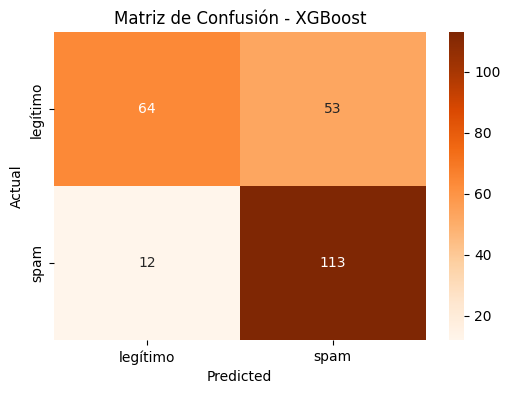

Número de fallos en las predicciones: 65


,mensaje,tipo,predicted
131,Este es un aviso de tu banco,legítimo,spam
539,Hemos extendido tu garantía sin costo adicional,legítimo,spam
1126,Construyamos juntos un mundo mejor,legítimo,spam
224,Haz una donación y ayuda a cambiar vidas,legítimo,spam
642,Salvemos más vidas con tu donación,legítimo,spam
...,...,...,...
298,Importante: cambios en nuestros términos y con...,legítimo,spam
1063,Divide tus pagos hasta en 24 meses,spam,legítimo
199,Esperamos que disfrutes de tu estancia en nues...,legítimo,spam
1171,Genera tu certificado tributario electronico,legítimo,spam


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Predicciones numéricas (devuelve 0 y 1)
xgb_preds_raw = xgb_pipeline.predict(test_documentos_procesados)

# 2. Convertimos a etiquetas de texto y creamos la Serie con el índice de test_df
xgb_predictions = ['spam' if p == 1 else 'legítimo' for p in xgb_preds_raw]
xgb_preds_series = pd.Series(xgb_predictions, index=test_df.index)

# 3. Métricas de evaluación
accuracy = accuracy_score(test_df['tipo'], xgb_predictions)
precision = precision_score(test_df['tipo'], xgb_predictions, pos_label='spam')
recall = recall_score(test_df['tipo'], xgb_predictions, pos_label='spam')
f1 = f1_score(test_df['tipo'], xgb_predictions, pos_label='spam')

print("\nEvaluación del modelo XGBoost en el conjunto de test:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Exhaustividad (Recall): {recall:.4f}")
print(f"Puntuación F1 (F1 Score): {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(test_df['tipo'], xgb_predictions))

# 4. Matriz de confusión
conf_matrix = confusion_matrix(test_df['tipo'], xgb_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

# 5. Documentos fallados (usando la Serie indexada para evitar el IndexError)
fallos = test_df[test_df['tipo'] != xgb_preds_series]
print(f"Número de fallos en las predicciones: {fallos.shape[0]}")
display(fallos.assign(predicted=xgb_preds_series[fallos.index]))

# LigthGBM

In [30]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Mapeo a valores binarios (0 = legítimo, 1 = spam) requerido por LightGBM
y_train_num = (train_df['tipo'] == 'spam').astype(int)

# Crea el vectorizador TF-IDF
tfidf_vectorizer_lgb = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features=None
)

# Crear el modelo LightGBM
lgb_classifier = LGBMClassifier(
    n_estimators=300,               # Número de árboles
    learning_rate=0.05,             # Tasa de aprendizaje
    num_leaves=31,                  # Control de complejidad (crecimiento leaf-wise)
    max_depth=6,                    # Límite de profundidad
    subsample=0.8,                  # Submuestreo de muestras
    random_state=RANDOM_SEED,       # Semilla para la reproducibilidad
    verbose=-1                      # Evita mensajes informativos en consola
)

# Montamos el pipeline de entrenamiento
lgb_pipeline = Pipeline(
    steps=[
        ('vectorizer', tfidf_vectorizer_lgb),
        ('classifier', lgb_classifier)
    ]
)

# Entrenamiento
lgb_pipeline.fit(
    train_documentos_procesados,
    y_train_num
)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


c:\Users\joral\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names



Evaluación del modelo LightGBM en el conjunto de test:
Exactitud (Accuracy): 0.6322
Precisión (Precision): 0.5900
Exhaustividad (Recall): 0.9440
Puntuación F1 (F1 Score): 0.7262

Reporte de clasificación:
              precision    recall  f1-score   support

    legítimo       0.83      0.30      0.44       117
        spam       0.59      0.94      0.73       125

    accuracy                           0.63       242
   macro avg       0.71      0.62      0.58       242
weighted avg       0.71      0.63      0.59       242



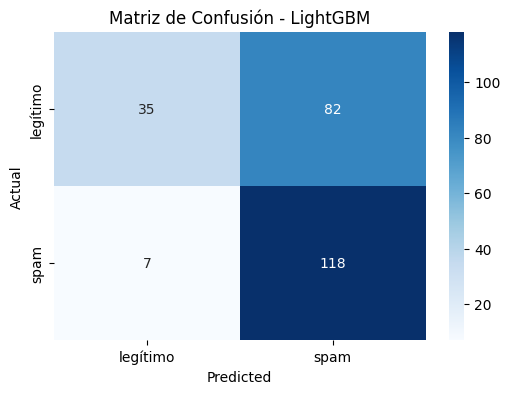

Número de fallos en las predicciones: 89


,mensaje,tipo,predicted
131,Este es un aviso de tu banco,legítimo,spam
539,Hemos extendido tu garantía sin costo adicional,legítimo,spam
905,Felicidades tu crédito fue pre-aprobado,legítimo,spam
1126,Construyamos juntos un mundo mejor,legítimo,spam
224,Haz una donación y ayuda a cambiar vidas,legítimo,spam
...,...,...,...
1171,Genera tu certificado tributario electronico,legítimo,spam
940,Comunicado: cambio temporal de sede,legítimo,spam
336,Aprende un nuevo idioma de forma divertida,spam,legítimo
595,Bienvenido a nuestro selecto club,legítimo,spam


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Predicciones numéricas (devuelve 0 y 1)
lgb_preds_raw = lgb_pipeline.predict(test_documentos_procesados)

# 2. Convertimos a etiquetas de texto y creamos la Serie con el índice de test_df[cite: 1]
lgb_predictions = ['spam' if p == 1 else 'legítimo' for p in lgb_preds_raw]
lgb_preds_series = pd.Series(lgb_predictions, index=test_df.index)

# 3. Métricas de evaluación[cite: 1]
accuracy = accuracy_score(test_df['tipo'], lgb_predictions)
precision = precision_score(test_df['tipo'], lgb_predictions, pos_label='spam')
recall = recall_score(test_df['tipo'], lgb_predictions, pos_label='spam')
f1 = f1_score(test_df['tipo'], lgb_predictions, pos_label='spam')

print("\nEvaluación del modelo LightGBM en el conjunto de test:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Exhaustividad (Recall): {recall:.4f}")
print(f"Puntuación F1 (F1 Score): {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(test_df['tipo'], lgb_predictions))

# 4. Matriz de confusión
conf_matrix = confusion_matrix(test_df['tipo'], lgb_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['legítimo', 'spam'], yticklabels=['legítimo', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - LightGBM')
plt.show()

# 5. Documentos fallados con índices alineados[cite: 1]
fallos = test_df[test_df['tipo'] != lgb_preds_series]
print(f"Número de fallos en las predicciones: {fallos.shape[0]}")
display(fallos.assign(predicted=lgb_preds_series[fallos.index]))